# Two-Stream Deepfake Detection Fusion

This notebook performs score-level fusion of two pre-trained deepfake detection models:
- **CLIP Stream**: Semantic-level features from CLIP vision encoder
- **Noise Stream**: Noise residual features from SRM + EfficientNetV2

**Workflow:**
1. Load both pre-trained models (best_clip.pth and best_noise_efficientnet.pth)
2. Run inference on test set with both models
3. Apply weighted average fusion: `p_final = (w * p_clip) + ((1 - w) * p_noise)`
4. Find optimal weight by testing w ∈ [0.0, 1.0] for best AUC-ROC
5. Evaluate combined performance and visualize results

**Key Components:**
- **No Training**: Pure inference and score-level fusion
- **Weighted Average**: Combines probabilities from both streams
- **Weight Optimization**: Search for best fusion weight using AUC-ROC
- **Comprehensive Metrics**: Accuracy, Precision, Recall, F1, AUC-ROC, Confusion Matrix

In [1]:
import os
import sys
import warnings
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

from transformers import CLIPVisionModel

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, 
    precision_score, recall_score, f1_score
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Add utils to path
sys.path.append('..')
sys.path.append('../utils')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1: Define Model Architectures

In [2]:
# Import model architectures
from utils.models import NoiseEfficientNet

# Define CLIP Classifier
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model_name='openai/clip-vit-large-patch14', num_classes=2):
        super(CLIPClassifier, self).__init__()
        
        self.clip_vision = CLIPVisionModel.from_pretrained(clip_model_name)
        
        # Freeze everything first
        for param in self.clip_vision.parameters():
            param.requires_grad = False
        
        # Unfreeze LayerNorms (LN-Tuning)
        for name, param in self.clip_vision.named_parameters():
            if 'norm' in name.lower():
                param.requires_grad = True
        
        hidden_size = self.clip_vision.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def forward(self, pixel_values, return_normalized_features=False):
        outputs = self.clip_vision(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        normalized_features = F.normalize(cls_token, p=2, dim=1)
        
        if return_normalized_features:
            return normalized_features
        
        logits = self.classifier(normalized_features)
        return logits

print("Model architectures defined successfully!")
print("  - CLIPClassifier: CLIP ViT-L/14 with LN-Tuning")
print("  - NoiseEfficientNet: SRM + EfficientNetV2-S")

Model architectures defined successfully!
  - CLIPClassifier: CLIP ViT-L/14 with LN-Tuning
  - NoiseEfficientNet: SRM + EfficientNetV2-S


## Step 2: Define Datasets for Both Streams

In [3]:
from utils.dataset import PrecomputedCLIPDataset, PrecomputedSRMDataset

# Create CLIP test dataset
clip_test_dataset = PrecomputedCLIPDataset(
    root_dir='../data/image_clip/test'
)

# Create Noise test dataset  
noise_test_dataset = PrecomputedSRMDataset(
    root_dir='../data/image_RGB/test'
)

print(f"\nCLIP Test Dataset: {len(clip_test_dataset)} samples")
print(f"Noise Test Dataset: {len(noise_test_dataset)} samples")

# Verify both datasets have same length
assert len(clip_test_dataset) == len(noise_test_dataset), "Datasets must have same length!"
print("\n✓ Datasets verified - same sample count")

Loaded 5981 precomputed CLIP tensors from ../data/image_clip/test
  Fake: 2992
  Real: 2989
Loaded 5981 precomputed RGB tensors from ../data/image_RGB/test
  Fake (Class 0): 2992
  Real (Class 1): 2989

CLIP Test Dataset: 5981 samples
Noise Test Dataset: 5981 samples

✓ Datasets verified - same sample count


## Step 3: Create DataLoaders

In [4]:
BATCH_SIZE = 64
NUM_WORKERS = 4

clip_test_loader = DataLoader(
    clip_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

noise_test_loader = DataLoader(
    noise_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\nDataLoaders created:")
print(f"  - CLIP Test: {len(clip_test_loader)} batches")
print(f"  - Noise Test: {len(noise_test_loader)} batches")
print(f"  - Batch size: {BATCH_SIZE}")


DataLoaders created:
  - CLIP Test: 94 batches
  - Noise Test: 94 batches
  - Batch size: 64


## Step 4: Load Pre-trained Models

In [ ]:
# Define model paths
CLIP_MODEL_PATH = '../saved_models/best_clip.pth'
NOISE_MODEL_PATH = '../saved_models/best_noise_efficientnet.pth'

print("Loading pre-trained models...\n")

# Load CLIP model
print("[1/2] Loading CLIP model...")
clip_model = CLIPClassifier(num_classes=2)
clip_checkpoint = torch.load(CLIP_MODEL_PATH, map_location=device)
clip_model.load_state_dict(clip_checkpoint['model_state_dict'])
clip_model = clip_model.to(device)
clip_model.eval()
print(f"  ✓ CLIP model loaded from {CLIP_MODEL_PATH}")
print(f"  ✓ Checkpoint epoch: {clip_checkpoint.get('epoch', 'N/A')}")
if 'val_auc' in clip_checkpoint:
    print(f"  ✓ Validation AUC: {clip_checkpoint['val_auc']:.4f}")
if 'val_acc' in clip_checkpoint:
    print(f"  ✓ Validation Accuracy: {clip_checkpoint['val_acc']:.2f}%")

# Load Noise model
print("\n[2/2] Loading Noise model...")
noise_model = NoiseEfficientNet()
noise_checkpoint = torch.load(NOISE_MODEL_PATH, map_location=device)
noise_model.load_state_dict(noise_checkpoint['model_state_dict'])
noise_model = noise_model.to(device)
noise_model.eval()
print(f"  ✓ Noise model loaded from {NOISE_MODEL_PATH}")
print(f"  ✓ Checkpoint epoch: {noise_checkpoint.get('epoch', 'N/A')}")
if 'val_auc' in noise_checkpoint:
    print(f"  ✓ Validation AUC: {noise_checkpoint['val_auc']:.4f}")
if 'val_acc' in noise_checkpoint:
    print(f"  ✓ Validation Accuracy: {noise_checkpoint['val_acc'] * 100:.2f}%")

print("\n✓ Both models loaded successfully and set to eval mode!")

Loading pre-trained models...

[1/2] Loading CLIP model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight   

  ✓ CLIP model loaded from ../models/best_clip.pth
  ✓ Checkpoint epoch: 47
  ✓ Validation AUC: 0.9844
  ✓ Validation Accuracy: 94.09%

[2/2] Loading Noise model...
  ✓ Noise model loaded from ../saved_models/best_noise_efficientnet.pth
  ✓ Checkpoint epoch: 23
  ✓ Validation AUC: 0.9636
  ✓ Validation Accuracy: 90.25%

✓ Both models loaded successfully and set to eval mode!


## Step 5: Define Normalization for Each Stream

In [6]:
import torchvision.transforms.functional as TF

# CLIP normalization
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1).to(device)
CLIP_STD = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1).to(device)

def normalize_clip(x):
    """Normalize for CLIP model (3-channel)"""
    return (x - CLIP_MEAN) / CLIP_STD

def normalize_noise(x):
    """
    Normalize 3-channel SRM noise residuals to [-1, 1] range.
    This matches the training preprocessing:
    1. Clamp to [-3, 3] (respects zero-mean Laplacian distribution)
    2. Divide by 3.0 to normalize to [-1, 1]
    """
    # Truncate noise residuals to [-3, 3]
    x = torch.clamp(x, min=-3.0, max=3.0)
    # Normalize to [-1, 1] range
    return x / 3.0

print("Normalization functions defined:")
print("  - CLIP: Custom CLIP normalization (3-channel RGB)")
print("  - Noise: 3-channel RGB → SRM → Clamp[-3,3] → Divide by 3 (matches training)")

Normalization functions defined:
  - CLIP: Custom CLIP normalization (3-channel RGB)
  - Noise: 3-channel RGB → SRM → Clamp[-3,3] → Divide by 3 (matches training)


## Step 6: Define SRM Filter for Noise Stream

In [7]:
from utils.models import SRMConv2d

# Initialize SRM filter with 3 channels for RGB input
srm_filter = SRMConv2d(in_channels=3).to(device)
srm_filter.eval()

print("SRM filter initialized with 3 channels and moved to GPU")

SRM filter initialized with 3 channels and moved to GPU


## Step 7: Run Inference on Both Models

In [8]:
print("Running inference on test set...\n")

all_labels = []
all_clip_probs = []
all_noise_probs = []

# Disable gradient computation
with torch.no_grad():
    # Create progress bar
    pbar = tqdm(zip(clip_test_loader, noise_test_loader), 
                total=len(clip_test_loader),
                desc="Inference")
    
    for (clip_data, clip_labels), (noise_data, noise_labels) in pbar:
        # Verify labels match
        assert torch.all(clip_labels == noise_labels), "Labels mismatch between streams!"
        
        # Move to device
        clip_data = clip_data.to(device)
        noise_data = noise_data.to(device)
        labels = clip_labels.to(device)
        
        # === CLIP Stream Processing ===
        clip_normalized = normalize_clip(clip_data)
        clip_logits = clip_model(clip_normalized)
        clip_probs = F.softmax(clip_logits, dim=1)
        clip_prob_fake = clip_probs[:, 0]  # Class 0 = Fake
        
        # === Noise Stream Processing ===
        # Step 1: Scale to [0, 255] range for SRM processing (tensors are in [0,1])
        noise_data_scaled = noise_data * 255.0
        
        # Step 2: Apply 3-channel SRM filter directly on RGB (B, 3, H, W) -> (B, 3, H, W)
        noise_srm = srm_filter(noise_data_scaled)
        
        # Step 3: Normalize the 3-channel SRM output (clamp + divide by 3)
        noise_normalized = normalize_noise(noise_srm)
        
        # Step 4: Pass through model
        noise_logits_raw = noise_model(noise_normalized).squeeze(1)
        
        # Step 5: Convert binary output to probabilities
        # noise_logits_raw: high value = Real, low value = Fake
        noise_prob_real = torch.sigmoid(noise_logits_raw)
        noise_prob_fake = 1 - noise_prob_real  # P(Fake) = 1 - P(Real)
        
        # Store results
        all_labels.extend(labels.cpu().numpy())
        all_clip_probs.extend(clip_prob_fake.cpu().numpy())
        all_noise_probs.extend(noise_prob_fake.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_clip_probs = np.array(all_clip_probs)
all_noise_probs = np.array(all_noise_probs)

print(f"\n✓ Inference complete!")
print(f"  Total samples: {len(all_labels)}")
print(f"  Fake samples (Class 0): {np.sum(all_labels == 0)}")
print(f"  Real samples (Class 1): {np.sum(all_labels == 1)}")

Running inference on test set...



Inference: 100%|██████████| 94/94 [01:50<00:00,  1.18s/it]


✓ Inference complete!
  Total samples: 5981
  Fake samples (Class 0): 2992
  Real samples (Class 1): 2989


## Step 8: Evaluate Individual Model Performance

In [9]:
print("="*60)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*60)

# CLIP Stream Performance
# all_clip_probs contains P(Fake), so we predict Fake when > 0.5
# Predict: class 0 (Fake) if P(Fake) > 0.5, else class 1 (Real)
clip_preds = (all_clip_probs <= 0.5).astype(int)  # 1=Real, 0=Fake

# For AUC: use Fake-as-positive labels with P(Fake) directly
labels_fake_positive = (all_labels == 0).astype(int)
clip_auc = roc_auc_score(labels_fake_positive, all_clip_probs)

# Calculate accuracy: comparing predicted class (0 or 1) with true label
clip_acc = np.mean(clip_preds == all_labels)

# For Precision/Recall/F1, we specify pos_label=0 (Fake)
clip_precision = precision_score(all_labels, clip_preds, pos_label=0)
clip_recall = recall_score(all_labels, clip_preds, pos_label=0)
clip_f1 = f1_score(all_labels, clip_preds, pos_label=0)

print("\n[CLIP Stream]")
print(f"  Accuracy:  {clip_acc:.4f}")
print(f"  AUC-ROC:   {clip_auc:.4f}")
print(f"  Precision: {clip_precision:.4f} (Fake class)")
print(f"  Recall:    {clip_recall:.4f} (Fake class)")
print(f"  F1-Score:  {clip_f1:.4f} (Fake class)")

# Noise Stream Performance
# all_noise_probs contains P(Fake), same logic as CLIP
noise_preds = (all_noise_probs <= 0.5).astype(int)  # 1=Real, 0=Fake
noise_auc = roc_auc_score(labels_fake_positive, all_noise_probs)
noise_acc = np.mean(noise_preds == all_labels)
noise_precision = precision_score(all_labels, noise_preds, pos_label=0)
noise_recall = recall_score(all_labels, noise_preds, pos_label=0)
noise_f1 = f1_score(all_labels, noise_preds, pos_label=0)

print("\n[Noise Stream]")
print(f"  Accuracy:  {noise_acc:.4f}")
print(f"  AUC-ROC:   {noise_auc:.4f}")
print(f"  Precision: {noise_precision:.4f} (Fake class)")
print(f"  Recall:    {noise_recall:.4f} (Fake class)")
print(f"  F1-Score:  {noise_f1:.4f} (Fake class)")

INDIVIDUAL MODEL PERFORMANCE

[CLIP Stream]
  Accuracy:  0.9405
  AUC-ROC:   0.9845
  Precision: 0.9492 (Fake class)
  Recall:    0.9308 (Fake class)
  F1-Score:  0.9399 (Fake class)

[Noise Stream]
  Accuracy:  0.9112
  AUC-ROC:   0.9636
  Precision: 0.9304 (Fake class)
  Recall:    0.8890 (Fake class)
  F1-Score:  0.9092 (Fake class)


## Step 9: Find Optimal Fusion Weight


WEIGHT OPTIMIZATION FOR FUSION

Optimal Weight: 0.55
  - CLIP contribution: 55.0%
  - Noise contribution: 45.0%

Best AUC-ROC: 0.9896
Best Accuracy: 0.9545


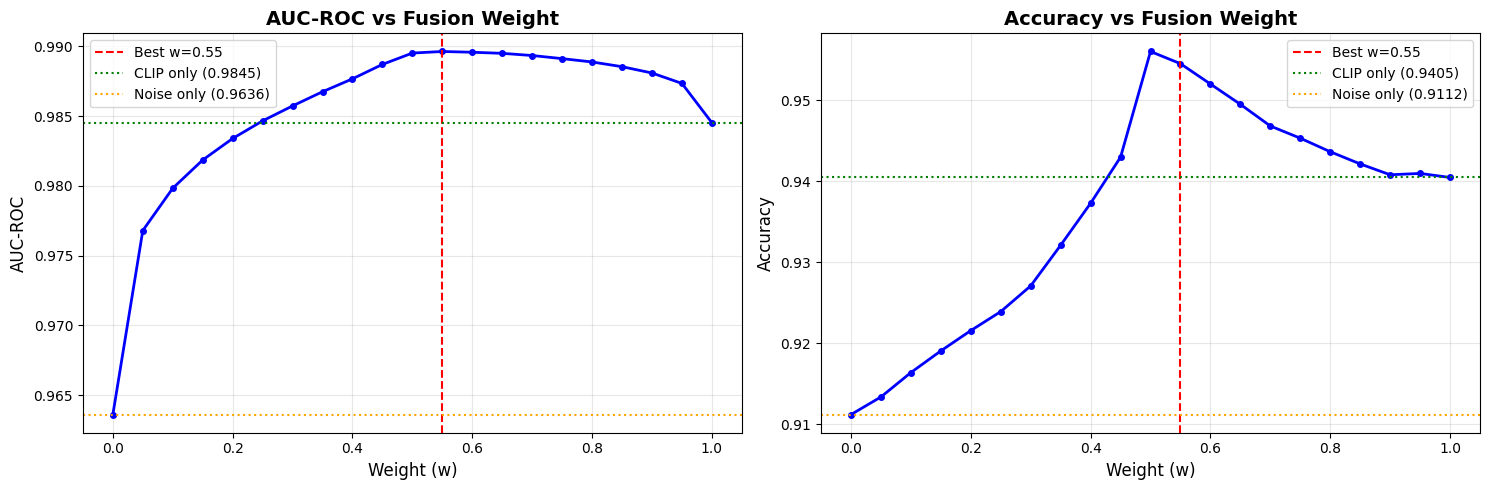


Weight search complete: tested 21 weights from 0.0 to 1.0


In [10]:
print("\n" + "="*60)
print("WEIGHT OPTIMIZATION FOR FUSION")
print("="*60)

# Test different weights
weights = np.arange(0.0, 1.01, 0.05)
auc_scores = []
acc_scores = []

for w in weights:
    # Weighted fusion
    fused_probs = w * all_clip_probs + (1 - w) * all_noise_probs
    
    # Calculate AUC with Fake as positive class
    labels_fake_positive = (all_labels == 0).astype(int)
    auc_score = roc_auc_score(labels_fake_positive, fused_probs)
    auc_scores.append(auc_score)
    
    # Calculate accuracy
    fused_preds = (fused_probs <= 0.5).astype(int)  # 1=Real, 0=Fake
    acc_score = np.mean(fused_preds == all_labels)
    acc_scores.append(acc_score)

# Find best weight
best_idx = np.argmax(auc_scores)
best_weight = weights[best_idx]
best_auc = auc_scores[best_idx]
best_acc = acc_scores[best_idx]

print(f"\nOptimal Weight: {best_weight:.2f}")
print(f"  - CLIP contribution: {best_weight:.1%}")
print(f"  - Noise contribution: {(1-best_weight):.1%}")
print(f"\nBest AUC-ROC: {best_auc:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")

# Plot weight optimization curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# AUC vs Weight
ax1.plot(weights, auc_scores, 'b-', linewidth=2, marker='o', markersize=4)
ax1.axvline(best_weight, color='r', linestyle='--', label=f'Best w={best_weight:.2f}')
ax1.axhline(clip_auc, color='g', linestyle=':', label=f'CLIP only ({clip_auc:.4f})')
ax1.axhline(noise_auc, color='orange', linestyle=':', label=f'Noise only ({noise_auc:.4f})')
ax1.set_xlabel('Weight (w)', fontsize=12)
ax1.set_ylabel('AUC-ROC', fontsize=12)
ax1.set_title('AUC-ROC vs Fusion Weight', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Accuracy vs Weight
ax2.plot(weights, acc_scores, 'b-', linewidth=2, marker='o', markersize=4)
ax2.axvline(best_weight, color='r', linestyle='--', label=f'Best w={best_weight:.2f}')
ax2.axhline(clip_acc, color='g', linestyle=':', label=f'CLIP only ({clip_acc:.4f})')
ax2.axhline(noise_acc, color='orange', linestyle=':', label=f'Noise only ({noise_acc:.4f})')
ax2.set_xlabel('Weight (w)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy vs Fusion Weight', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nWeight search complete: tested {len(weights)} weights from 0.0 to 1.0")

## Step 10: Evaluate Fused Model Performance

In [11]:
# Use best weight for final fusion
fused_probs = best_weight * all_clip_probs + (1 - best_weight) * all_noise_probs
fused_preds = (fused_probs <= 0.5).astype(int)  # 1=Real, 0=Fake

# Calculate metrics
fused_acc = np.mean(fused_preds == all_labels)
labels_fake_positive = (all_labels == 0).astype(int)
fused_auc = roc_auc_score(labels_fake_positive, fused_probs)
fused_precision = precision_score(all_labels, fused_preds, pos_label=0)
fused_recall = recall_score(all_labels, fused_preds, pos_label=0)
fused_f1 = f1_score(all_labels, fused_preds, pos_label=0)

print("\n" + "="*60)
print("FUSED MODEL PERFORMANCE")
print("="*60)
print(f"\nFusion Weight: {best_weight:.2f} (CLIP) + {1-best_weight:.2f} (Noise)")
print(f"\n  Accuracy:  {fused_acc:.4f}")
print(f"  AUC-ROC:   {fused_auc:.4f}")
print(f"  Precision: {fused_precision:.4f} (Fake class)")
print(f"  Recall:    {fused_recall:.4f} (Fake class)")
print(f"  F1-Score:  {fused_f1:.4f} (Fake class)")

# Performance improvement
print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"\nAUC-ROC Improvement:")
print(f"  vs CLIP:  {fused_auc - clip_auc:+.4f} ({((fused_auc/clip_auc - 1)*100):+.2f}%)")
print(f"  vs Noise: {fused_auc - noise_auc:+.4f} ({((fused_auc/noise_auc - 1)*100):+.2f}%)")
print(f"\nAccuracy Improvement:")
print(f"  vs CLIP:  {fused_acc - clip_acc:+.4f} ({((fused_acc/clip_acc - 1)*100):+.2f}%)")
print(f"  vs Noise: {fused_acc - noise_acc:+.4f} ({((fused_acc/noise_acc - 1)*100):+.2f}%)")


FUSED MODEL PERFORMANCE

Fusion Weight: 0.55 (CLIP) + 0.45 (Noise)

  Accuracy:  0.9545
  AUC-ROC:   0.9896
  Precision: 0.9635 (Fake class)
  Recall:    0.9449 (Fake class)
  F1-Score:  0.9541 (Fake class)

PERFORMANCE COMPARISON

AUC-ROC Improvement:
  vs CLIP:  +0.0051 (+0.52%)
  vs Noise: +0.0260 (+2.70%)

Accuracy Improvement:
  vs CLIP:  +0.0140 (+1.49%)
  vs Noise: +0.0433 (+4.75%)


## Step 11: Confusion Matrix Comparison

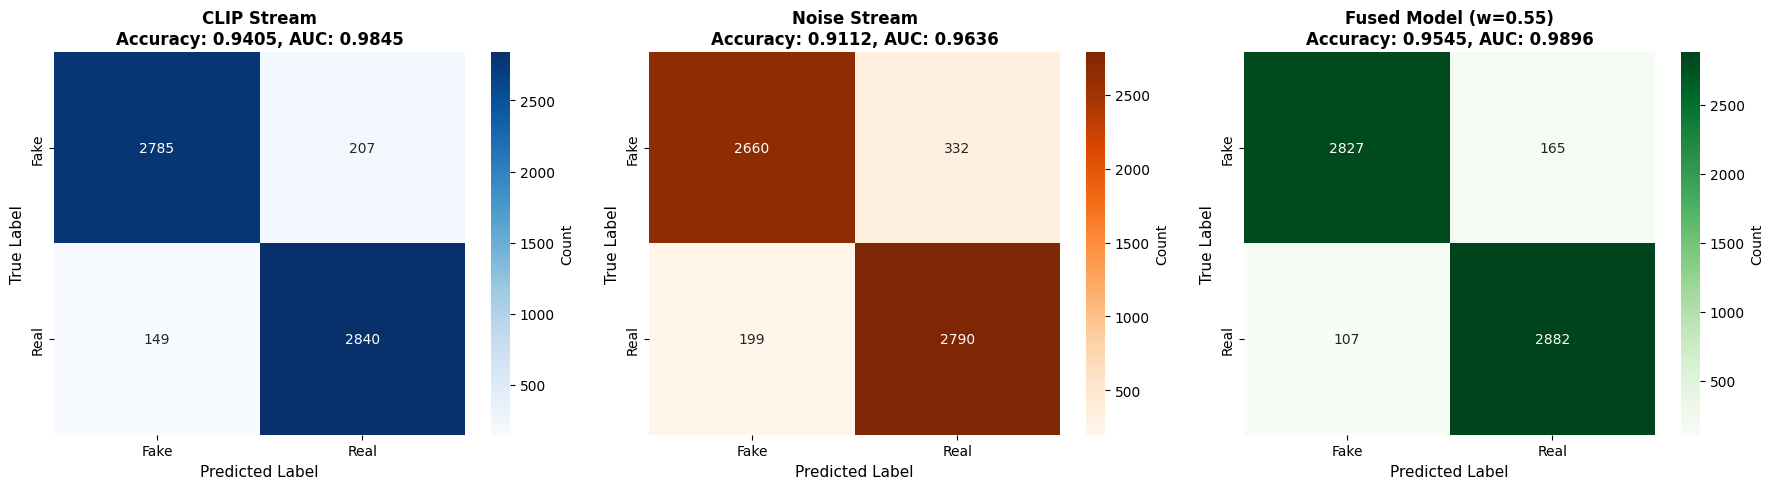

In [12]:
# Calculate confusion matrices
cm_clip = confusion_matrix(all_labels, clip_preds)
cm_noise = confusion_matrix(all_labels, noise_preds)
cm_fused = confusion_matrix(all_labels, fused_preds)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CLIP Confusion Matrix
sns.heatmap(cm_clip, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'CLIP Stream\nAccuracy: {clip_acc:.4f}, AUC: {clip_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Noise Confusion Matrix
sns.heatmap(cm_noise, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Noise Stream\nAccuracy: {noise_acc:.4f}, AUC: {noise_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

# Fused Confusion Matrix
sns.heatmap(cm_fused, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title(f'Fused Model (w={best_weight:.2f})\nAccuracy: {fused_acc:.4f}, AUC: {fused_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11)
axes[2].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

## Step 12: ROC Curve Comparison

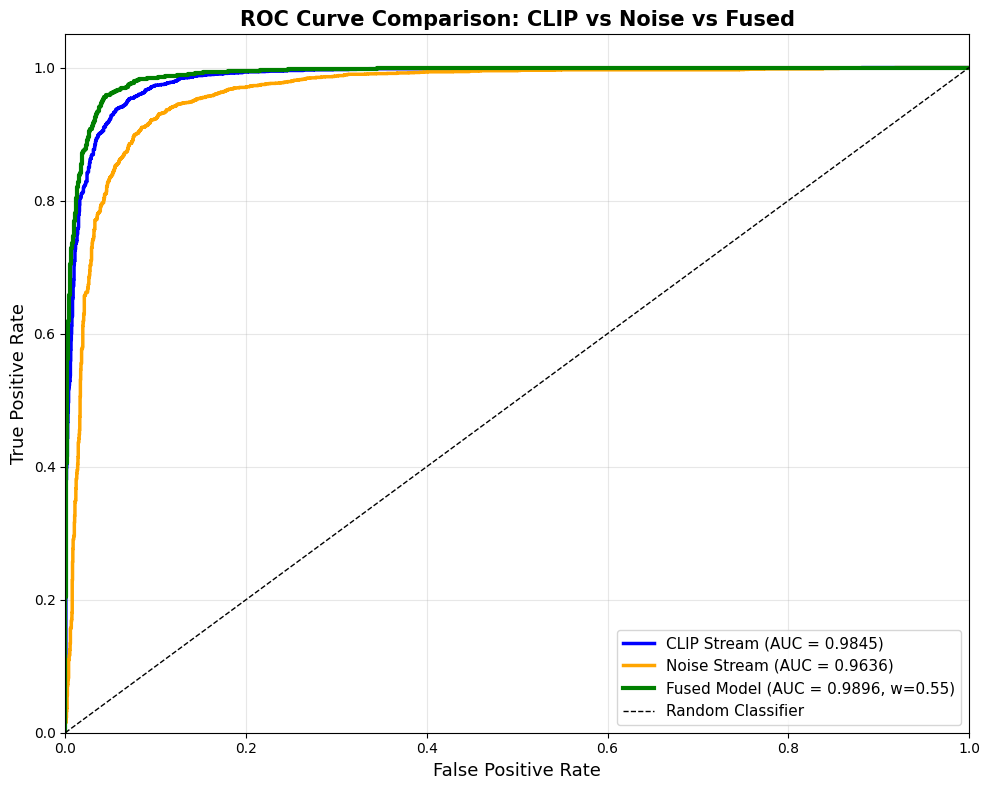

In [13]:
# Calculate ROC curves with Fake as positive class
labels_fake_positive = (all_labels == 0).astype(int)
fpr_clip, tpr_clip, _ = roc_curve(labels_fake_positive, all_clip_probs)
fpr_noise, tpr_noise, _ = roc_curve(labels_fake_positive, all_noise_probs)
fpr_fused, tpr_fused, _ = roc_curve(labels_fake_positive, fused_probs)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_clip, tpr_clip, 'b-', linewidth=2.5, 
         label=f'CLIP Stream (AUC = {clip_auc:.4f})')
plt.plot(fpr_noise, tpr_noise, 'orange', linewidth=2.5, 
         label=f'Noise Stream (AUC = {noise_auc:.4f})')
plt.plot(fpr_fused, tpr_fused, 'g-', linewidth=3, 
         label=f'Fused Model (AUC = {fused_auc:.4f}, w={best_weight:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison: CLIP vs Noise vs Fused', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13: Classification Reports

In [14]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

print("\n[CLIP Stream]")
print(classification_report(all_labels, clip_preds, 
                           target_names=['Fake', 'Real'], digits=4))

print("\n[Noise Stream]")
print(classification_report(all_labels, noise_preds, 
                           target_names=['Fake', 'Real'], digits=4))

print("\n[Fused Model]")
print(classification_report(all_labels, fused_preds, 
                           target_names=['Fake', 'Real'], digits=4))


DETAILED CLASSIFICATION REPORTS

[CLIP Stream]
              precision    recall  f1-score   support

        Fake     0.9492    0.9308    0.9399      2992
        Real     0.9321    0.9502    0.9410      2989

    accuracy                         0.9405      5981
   macro avg     0.9406    0.9405    0.9405      5981
weighted avg     0.9406    0.9405    0.9405      5981


[Noise Stream]
              precision    recall  f1-score   support

        Fake     0.9304    0.8890    0.9092      2992
        Real     0.8937    0.9334    0.9131      2989

    accuracy                         0.9112      5981
   macro avg     0.9120    0.9112    0.9112      5981
weighted avg     0.9120    0.9112    0.9112      5981


[Fused Model]
              precision    recall  f1-score   support

        Fake     0.9635    0.9449    0.9541      2992
        Real     0.9458    0.9642    0.9549      2989

    accuracy                         0.9545      5981
   macro avg     0.9547    0.9545    0.9545      

## Step 14: Probability Distribution Analysis

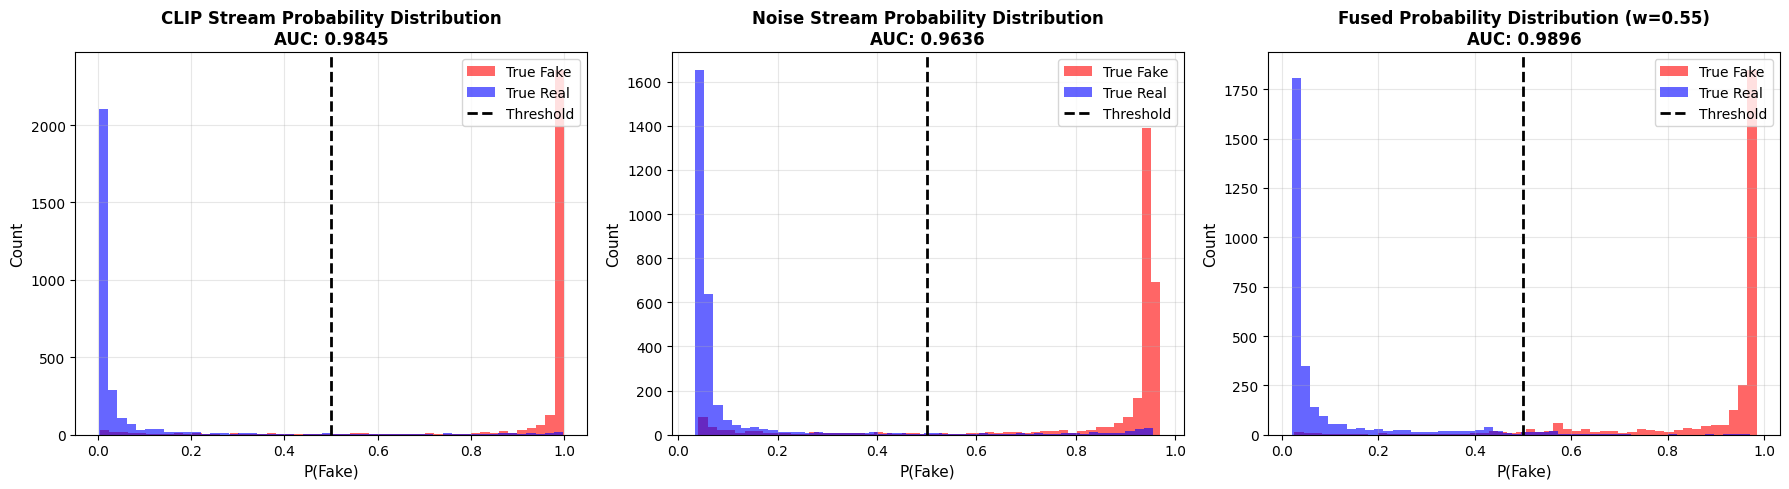

In [15]:
# Separate probabilities by true class
fake_mask = (all_labels == 0)
real_mask = (all_labels == 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CLIP Distribution
axes[0].hist(all_clip_probs[fake_mask], bins=50, alpha=0.6, label='True Fake', color='red')
axes[0].hist(all_clip_probs[real_mask], bins=50, alpha=0.6, label='True Real', color='blue')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('P(Fake)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title(f'CLIP Stream Probability Distribution\nAUC: {clip_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Noise Distribution
axes[1].hist(all_noise_probs[fake_mask], bins=50, alpha=0.6, label='True Fake', color='red')
axes[1].hist(all_noise_probs[real_mask], bins=50, alpha=0.6, label='True Real', color='blue')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('P(Fake)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Noise Stream Probability Distribution\nAUC: {noise_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Fused Distribution
axes[2].hist(fused_probs[fake_mask], bins=50, alpha=0.6, label='True Fake', color='red')
axes[2].hist(fused_probs[real_mask], bins=50, alpha=0.6, label='True Real', color='blue')
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[2].set_xlabel('P(Fake)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title(f'Fused Probability Distribution (w={best_weight:.2f})\nAUC: {fused_auc:.4f}', 
                  fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 15: Summary and Conclusions

In [16]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("\n📊 Model Performance Comparison:")
print(f"\n{'Model':<20} {'Accuracy':<12} {'AUC-ROC':<12} {'F1-Score':<12}")
print("-" * 56)
print(f"{'CLIP Stream':<20} {clip_acc:<12.4f} {clip_auc:<12.4f} {clip_f1:<12.4f}")
print(f"{'Noise Stream':<20} {noise_acc:<12.4f} {noise_auc:<12.4f} {noise_f1:<12.4f}")
print(f"{'Fused Model':<20} {fused_acc:<12.4f} {fused_auc:<12.4f} {fused_f1:<12.4f}")

print("\n🎯 Key Findings:")
print(f"  1. Optimal fusion weight: {best_weight:.2f} (CLIP) + {1-best_weight:.2f} (Noise)")
print(f"  2. Best individual model: {'CLIP' if clip_auc > noise_auc else 'Noise'} "
      f"(AUC: {max(clip_auc, noise_auc):.4f})")
print(f"  3. Fusion provides: {fused_auc - max(clip_auc, noise_auc):+.4f} AUC improvement")

is_better = fused_auc > clip_auc and fused_auc > noise_auc
print(f"\n✅ Fusion Result: {'SUCCESS' if is_better else 'NEEDS INVESTIGATION'}")
if is_better:
    print("   The fused model outperforms both individual models!")
else:
    print("   The fused model did not improve over the best individual model.")
    print("   Consider: different fusion methods, model calibration, or feature-level fusion.")

print("\n" + "="*60)
print("Analysis complete!")
print("="*60)


FINAL SUMMARY

📊 Model Performance Comparison:

Model                Accuracy     AUC-ROC      F1-Score    
--------------------------------------------------------
CLIP Stream          0.9405       0.9845       0.9399      
Noise Stream         0.9112       0.9636       0.9092      
Fused Model          0.9545       0.9896       0.9541      

🎯 Key Findings:
  1. Optimal fusion weight: 0.55 (CLIP) + 0.45 (Noise)
  2. Best individual model: CLIP (AUC: 0.9845)
  3. Fusion provides: +0.0051 AUC improvement

✅ Fusion Result: SUCCESS
   The fused model outperforms both individual models!

Analysis complete!


## Step 16: Evaluation by Manipulation Type

In [ ]:
import re
from collections import defaultdict
from pathlib import Path
import time

def extract_manipulation_type(filepath):
    """
    Extract manipulation type from file path or filename.
    
    Optimized version with cached type lists and early returns.
    
    Supported types:
    - FaceForensics++: Deepfakes, Face2Face, FaceSwap, NeuralTextures, FaceShifter
    - ArtiFact: progan, stylegan, stargan, sfhq, face_synthetics, stable-diffusion
    - Real (3 types): CelebA-HQ, FFHQ, FF++ C23
    
    Returns:
        str: Manipulation type (e.g., 'CelebA-HQ', 'Deepfakes', 'progan', etc.)
    """
    filepath = str(filepath).replace('\\', '/')
    filepath_lower = filepath.lower()
    filename = Path(filepath).stem.lower()
    
    # Type mappings (defined once as function attribute for caching)
    if not hasattr(extract_manipulation_type, '_type_map'):
        extract_manipulation_type._ffpp_types = ['deepfakes', 'face2face', 'faceswap', 'neuraltextures', 'faceshifter']
        extract_manipulation_type._artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
        extract_manipulation_type._type_display = {
            'deepfakes': 'Deepfakes', 'face2face': 'Face2Face', 'faceswap': 'FaceSwap',
            'neuraltextures': 'NeuralTextures', 'faceshifter': 'FaceShifter',
            'progan': 'progan', 'stylegan': 'stylegan', 'stargan': 'stargan',
            'sfhq': 'sfhq', 'face_synthetics': 'face_synthetics', 'stable-diffusion': 'stable-diffusion'
        }
        extract_manipulation_type._type_map = True
    
    # Check if real image
    if '/real/' in filepath_lower:
        if 'celebahq' in filename:
            return 'CelebA-HQ'
        elif 'ffhq' in filename:
            return 'FFHQ'
        elif filename.startswith('real_') and '_' in filename[5:8]:
            return 'FF++ C23'
        else:
            # Unknown real types are from FF++ C23 (YouTube videos)
            return 'FF++ C23'
    
    # Check if fake image
    if '/fake/' in filepath_lower:
        for manip_type in extract_manipulation_type._ffpp_types + extract_manipulation_type._artifact_types:
            if manip_type in filename:
                return extract_manipulation_type._type_display.get(manip_type, manip_type)
        return 'Unknown'
    
    return 'Unknown'

def evaluate_by_manipulation_type_from_predictions(file_paths, clip_preds, noise_preds, fused_preds, labels):
    """
    Evaluate all three models by manipulation type using pre-computed predictions.
    
    Args:
        file_paths: List of file paths for test samples
        clip_preds: CLIP stream predictions
        noise_preds: Noise stream predictions
        fused_preds: Fused model predictions
        labels: Ground truth labels
        
    Returns:
        dict: Dictionary with manipulation types and their predictions for all models
    """
    import time
    start_time = time.time()
    
    num_samples = len(file_paths)
    print(f"Analyzing {num_samples} test samples by manipulation type...")
    
    # Convert to numpy if needed
    if not isinstance(clip_preds, np.ndarray):
        clip_preds = np.array(clip_preds)
    if not isinstance(noise_preds, np.ndarray):
        noise_preds = np.array(noise_preds)
    if not isinstance(fused_preds, np.ndarray):
        fused_preds = np.array(fused_preds)
    if not isinstance(labels, np.ndarray):
        labels = np.array(labels)
    
    # Extract manipulation types (vectorized)
    print("Mapping samples to manipulation types...")
    manip_types = [extract_manipulation_type(fp) for fp in file_paths]
    
    # Group by manipulation type using numpy masks (vectorized, much faster)
    unique_types = list(set(manip_types))
    manip_results = {}
    
    manip_types_array = np.array(manip_types)
    for manip_type in unique_types:
        mask = (manip_types_array == manip_type)
        manip_results[manip_type] = {
            'labels': labels[mask],
            'clip_preds': clip_preds[mask],
            'noise_preds': noise_preds[mask],
            'fused_preds': fused_preds[mask]
        }
    
    total_time = time.time() - start_time
    print(f"Analysis completed in {total_time:.2f}s")
    
    return manip_results

def print_manipulation_type_results(manip_results):
    """
    Print formatted results by manipulation type for all three models.
    
    Args:
        manip_results: Dictionary with manipulation types and their predictions
    """
    ff_types = ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter']
    artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
    real_types = ['CelebA-HQ', 'FFHQ', 'FF++ C23']
    
    print("=" * 120)
    print("EVALUATION RESULTS BY MANIPULATION TYPE - ALL MODELS")
    print("=" * 120)
    print()
    
    print(f"{'Category':<25} {'Total':<12} {'CLIP Acc':<15} {'Noise Acc':<15} {'Fused Acc':<15} {'Improvement':<15}")
    print("-" * 120)
    
    # Real images
    print("Real Images:")
    print("-" * 120)
    
    real_total = 0
    real_clip_correct = 0
    real_noise_correct = 0
    real_fused_correct = 0
    
    for manip_type in real_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            clip_preds = manip_results[manip_type]['clip_preds']
            noise_preds = manip_results[manip_type]['noise_preds']
            fused_preds = manip_results[manip_type]['fused_preds']
            
            total = len(labels)
            clip_correct = np.sum(clip_preds == labels)
            noise_correct = np.sum(noise_preds == labels)
            fused_correct = np.sum(fused_preds == labels)
            
            clip_acc = 100.0 * clip_correct / total if total > 0 else 0.0
            noise_acc = 100.0 * noise_correct / total if total > 0 else 0.0
            fused_acc = 100.0 * fused_correct / total if total > 0 else 0.0
            
            # Calculate improvement over best individual stream
            best_individual = max(clip_acc, noise_acc)
            improvement = fused_acc - best_individual
            
            real_total += total
            real_clip_correct += clip_correct
            real_noise_correct += noise_correct
            real_fused_correct += fused_correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {clip_acc:>13.2f}% {noise_acc:>13.2f}% {fused_acc:>13.2f}% {improvement:>+13.2f}%")
    
    print()
    
    # FaceForensics++ fakes
    print("FaceForensics++ Fakes:")
    print("-" * 120)
    
    ff_total = 0
    ff_clip_correct = 0
    ff_noise_correct = 0
    ff_fused_correct = 0
    
    for manip_type in ff_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            clip_preds = manip_results[manip_type]['clip_preds']
            noise_preds = manip_results[manip_type]['noise_preds']
            fused_preds = manip_results[manip_type]['fused_preds']
            
            total = len(labels)
            clip_correct = np.sum(clip_preds == labels)
            noise_correct = np.sum(noise_preds == labels)
            fused_correct = np.sum(fused_preds == labels)
            
            clip_acc = 100.0 * clip_correct / total if total > 0 else 0.0
            noise_acc = 100.0 * noise_correct / total if total > 0 else 0.0
            fused_acc = 100.0 * fused_correct / total if total > 0 else 0.0
            
            # Calculate improvement over best individual stream
            best_individual = max(clip_acc, noise_acc)
            improvement = fused_acc - best_individual
            
            ff_total += total
            ff_clip_correct += clip_correct
            ff_noise_correct += noise_correct
            ff_fused_correct += fused_correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {clip_acc:>13.2f}% {noise_acc:>13.2f}% {fused_acc:>13.2f}% {improvement:>+13.2f}%")
    
    print()
    
    # ArtiFact fakes
    print("ArtiFact Fakes:")
    print("-" * 120)
    
    artifact_total = 0
    artifact_clip_correct = 0
    artifact_noise_correct = 0
    artifact_fused_correct = 0
    
    for manip_type in artifact_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            clip_preds = manip_results[manip_type]['clip_preds']
            noise_preds = manip_results[manip_type]['noise_preds']
            fused_preds = manip_results[manip_type]['fused_preds']
            
            total = len(labels)
            clip_correct = np.sum(clip_preds == labels)
            noise_correct = np.sum(noise_preds == labels)
            fused_correct = np.sum(fused_preds == labels)
            
            clip_acc = 100.0 * clip_correct / total if total > 0 else 0.0
            noise_acc = 100.0 * noise_correct / total if total > 0 else 0.0
            fused_acc = 100.0 * fused_correct / total if total > 0 else 0.0
            
            # Calculate improvement over best individual stream
            best_individual = max(clip_acc, noise_acc)
            improvement = fused_acc - best_individual
            
            artifact_total += total
            artifact_clip_correct += clip_correct
            artifact_noise_correct += noise_correct
            artifact_fused_correct += fused_correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {clip_acc:>13.2f}% {noise_acc:>13.2f}% {fused_acc:>13.2f}% {improvement:>+13.2f}%")
    
    print("-" * 120)
    
    # Overall statistics
    overall_total = real_total + ff_total + artifact_total
    overall_clip_correct = real_clip_correct + ff_clip_correct + artifact_clip_correct
    overall_noise_correct = real_noise_correct + ff_noise_correct + artifact_noise_correct
    overall_fused_correct = real_fused_correct + ff_fused_correct + artifact_fused_correct
    
    overall_clip_acc = 100.0 * overall_clip_correct / overall_total if overall_total > 0 else 0.0
    overall_noise_acc = 100.0 * overall_noise_correct / overall_total if overall_total > 0 else 0.0
    overall_fused_acc = 100.0 * overall_fused_correct / overall_total if overall_total > 0 else 0.0
    
    best_overall = max(overall_clip_acc, overall_noise_acc)
    overall_improvement = overall_fused_acc - best_overall
    
    print(f"{'OVERALL':<25} {overall_total:<12} {overall_clip_acc:>13.2f}% {overall_noise_acc:>13.2f}% {overall_fused_acc:>13.2f}% {overall_improvement:>+13.2f}%")
    print("=" * 120)
    
    # Print any unclassified manipulation types
    all_known = set(real_types + ff_types + artifact_types)
    unknown_types = set(manip_results.keys()) - all_known
    
    if unknown_types:
        print()
        print("Unknown/Other Manipulation Types:")
        print("-" * 120)
        for manip_type in sorted(unknown_types):
            labels = manip_results[manip_type]['labels']
            clip_preds = manip_results[manip_type]['clip_preds']
            noise_preds = manip_results[manip_type]['noise_preds']
            fused_preds = manip_results[manip_type]['fused_preds']
            
            total = len(labels)
            clip_correct = np.sum(clip_preds == labels)
            noise_correct = np.sum(noise_preds == labels)
            fused_correct = np.sum(fused_preds == labels)
            
            clip_acc = 100.0 * clip_correct / total if total > 0 else 0.0
            noise_acc = 100.0 * noise_correct / total if total > 0 else 0.0
            fused_acc = 100.0 * fused_correct / total if total > 0 else 0.0
            
            best_individual = max(clip_acc, noise_acc)
            improvement = fused_acc - best_individual
            
            print(f"{'  ' + manip_type:<25} {total:<12} {clip_acc:>13.2f}% {noise_acc:>13.2f}% {fused_acc:>13.2f}% {improvement:>+13.2f}%")
        print("=" * 120)

# Run evaluation by manipulation type using pre-computed predictions
# This ensures consistency with the test accuracy reported above
manip_results = evaluate_by_manipulation_type_from_predictions(
    test_dataset.samples, 
    clip_preds,
    noise_preds,
    fused_preds,
    all_labels
)

# Debug: Print first few filenames to verify extraction works
print("\nDebug: Sample file paths and extracted types:")
for i, filepath in enumerate(test_dataset.samples[:10]):
    manip_type = extract_manipulation_type(filepath)
    print(f"  {i+1}. {Path(filepath).name} -> {manip_type}")
print()

print_manipulation_type_results(manip_results)